## **Random Forest**

### 1. Describe Data

Tahap ini bertujuan untuk memahami isi dan karakteristik dari data yang telah dikumpulkan sebelum dilakukan analisis lebih lanjut.

Penjelasan:
* Dataset terdiri dari 150 baris data dan 5 kolom (atribut).
* Empat atribut bertipe numerik (float), yaitu:

    * sepal_length
    * sepal_width
    * petal_length
    * petal_width

* Satu atribut bertipe kategorikal (teks), yaitu:

    * species

* Setiap baris merepresentasikan satu sampel bunga Iris.
* Dataset tidak memiliki nilai kosong (missing value).
* Struktur data berbentuk tabel dengan setiap kolom memiliki arti sebagai berikut:

    * sepal_length: panjang kelopak bunga (cm)
    * sepal_width: lebar kelopak bunga (cm)
    * petal_length: panjang mahkota bunga (cm)
    * petal_width: lebar mahkota bunga (cm)
    * species: jenis atau kelas bunga Iris

Tahap ini membantu memahami struktur dan karakteristik data sehingga dapat diketahui bagaimana data akan dianalisis pada tahap eksplorasi selanjutnya.


### 2. Preprocessing Data

Tahap preprocessing data dilakukan untuk mempersiapkan dataset sebelum masuk ke proses pemodelan. Pada tahap ini, data dibersihkan, dipilih, dan diubah ke format yang sesuai agar dapat diproses dengan baik oleh algoritma machine learning.

#### **a. Excel Reader**

Node Excel Reader digunakan untuk membaca dataset IRIS yang berbentuk file.Excel. Data yang berhasil dibaca akan ditampilkan dalam bentuk tabel yang berisi seluruh fitur dan target class.

#### **b. Table Partitioner**

Node Table Partitioner digunakan untuk membagi dataset menjadi dua bagian:

* Data Training $\rightarrow$ dikirim melalui port atas ke node Learner untuk melatih model.

* Data Testing $\rightarrow$ dikirim melalui port bawah ke node Predictor untuk menguji performa model.

Pembagian ini penting agar model yang dihasilkan tidak hanya "menghafal" data, tetapi benar-benar mampu melakukan prediksi pada data baru.

Sesuai dengan gambar Anda, proses partisi datanya adalah (70:30):

* 70% Data Training: Digunakan untuk melatih model (Decision Tree dan Random Forest) agar memahami pola-pola dalam data.

* 30% Data Testing: Digunakan untuk menguji seberapa akurat model tersebut dalam memprediksi label pada data yang belum pernah dipelajari sebelumnya.


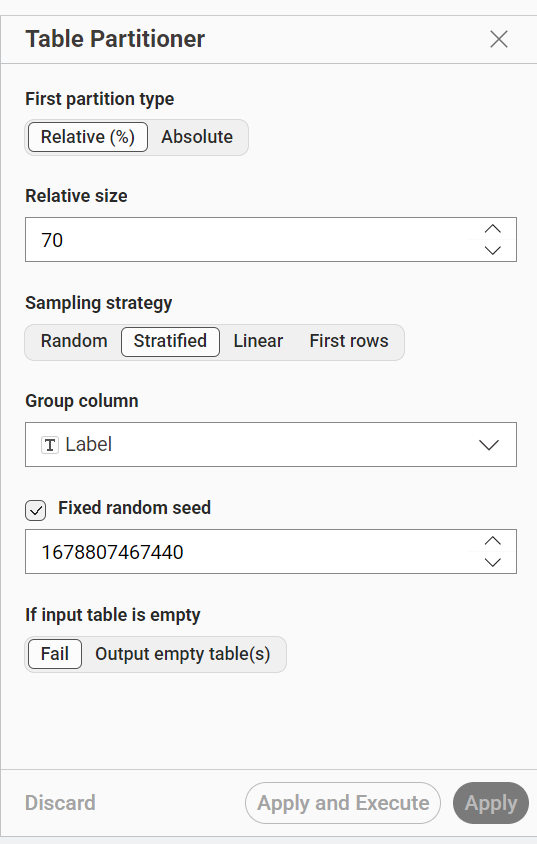

#### **c. Decision Tree Learner**

Node Decision Tree Learner digunakan untuk membangun model klasifikasi dalam bentuk struktur pohon keputusan:

* Root Node (Akar) $\rightarrow$ Merupakan titik awal pembagian data berdasarkan fitur yang paling berpengaruh.
* Leaf Node (Daun) $\rightarrow$ Merupakan hasil klasifikasi akhir (prediksi kategori).

Visualisasi ini membantu kita memahami logika "jika-maka" (if-then) yang digunakan model untuk mengambil keputusan.

Berdasarkan gambar dibawah, proses klasifikasinya adalah sebagai berikut:

* Total Data Training (1.400 baris): Terdiri dari 700 data "Tidak Subur" dan 700 data "Subur" (distribusi seimbang 50:50).

* Atribut Penentu (Kejenuhan Basa): Model memilih variabel "Kejenuhan Basa" sebagai pemisah utama.

* Logika Keputusan:
  * Jika Kejenuhan Basa $\le$ 58.96, maka data diklasifikasikan sebagai Tidak Subur (700 baris).
  * Jika Kejenuhan Basa > 58.96, maka data diklasifikasikan sebagai Subur (700 baris).

Detail Konfigurasi pada Gambar:

* **Class Column**: Menggunakan kolom Label sebagai target prediksi.

* **Quality Measure**: Menggunakan Gini Index untuk mengukur tingkat ketidakmurnian (impurity) data saat pembagian node.

* **Pruning Method**: Memilih No pruning, yang berarti pohon dibiarkan tumbuh maksimal tanpa dipotong untuk penyederhanaan

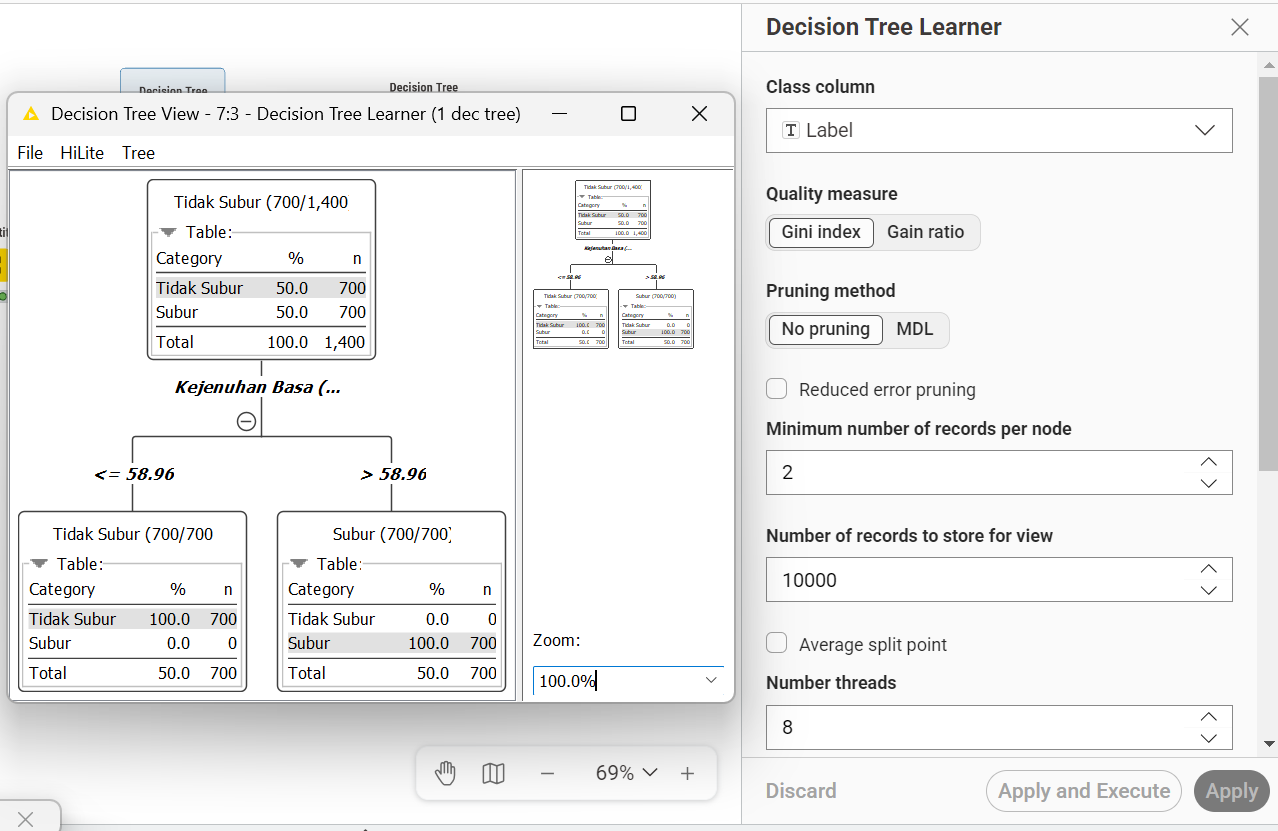



#### **d. Decision Tree View (JavaScript)**

Node Decision Tree View digunakan untuk menampilkan model klasifikasi dalam bentuk pohon agar alur logika komputer mudah dipahami manusia:

* Node Akar (Root) $\rightarrow$ Titik awal yang berisi seluruh dataset sebelum dipisahkan.
* Cabang (Branch) $\rightarrow$ Alur yang memisahkan data berdasarkan aturan atau kriteria tertentu.
* Daun (Leaf) $\rightarrow$ Hasil akhir klasifikasi (keputusan prediksi).

Berdasarkan visualisasi pada gambar dibawah, proses klasifikasinya adalah sebagai berikut:

* Akar Pohon (Root Node): Menampilkan total 1.400 data awal dengan keterangan kelas mayoritas "Tidak Subur" (700 dari 1.400 baris).

* Atribut Penentu (Kejenuhan Basa %): Variabel ini digunakan sebagai filter utama untuk membagi data.

* Logika Klasifikasi (700:700):

  * Jika Kejenuhan Basa $\le$ 58.96: Maka data masuk ke kategori Tidak Subur (Terdapat 700 baris data).
  * Jika Kejenuhan Basa > 58.96: Maka data masuk ke kategori Subur (Terdapat 700 baris data).

  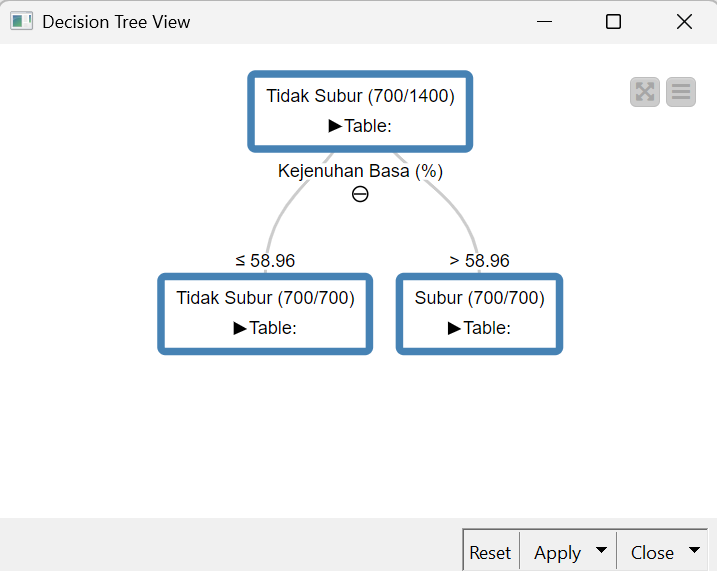


  Visualisasi ini menunjukkan bahwa model Anda sangat sederhana namun kuat, karena hanya dengan satu variabel (Kejenuhan Basa), model dapat memisahkan data secara sempurna menjadi dua kelompok yang berbeda.



#### **e. Decision Tree Predictor**

Node Decision Tree Predictor digunakan untuk menerapkan model pohon keputusan pada dataset:

* Penerapan Aturan $\rightarrow$ Menggunakan logika yang sudah dipelajari dari data training ke data baru.
* Klasifikasi $\rightarrow$ Menentukan kelas atau label akhir untuk setiap baris data berdasarkan kriteria yang ada.

Struktur pohon ini sangat penting untuk memastikan bahwa model bekerja secara konsisten saat menghadapi data di luar proses pelatihan.

Berdasarkan visualisasi pada gambar dibawah , detail datanya adalah sebagai berikut:

* Total Data (1.400 baris): Menampilkan distribusi awal di mana terdapat 700 data "Tidak Subur" dan 700 data "Subur" (50.0% banding 50.0%).

* Variabel Penentu (Kejenuhan Basa %): Ini adalah fitur tunggal yang digunakan untuk memisahkan seluruh dataset.

* Hasil Klasifikasi:

  * Cabang Kiri (Kejenuhan Basa % $\le$ ...): Menghasilkan 700 baris yang semuanya (100%) diklasifikasikan sebagai Tidak Subur.
  * Cabang Kanan (Kejenuhan Basa % > ...): Menghasilkan 700 baris yang semuanya (100%) diklasifikasikan sebagai Subur.


  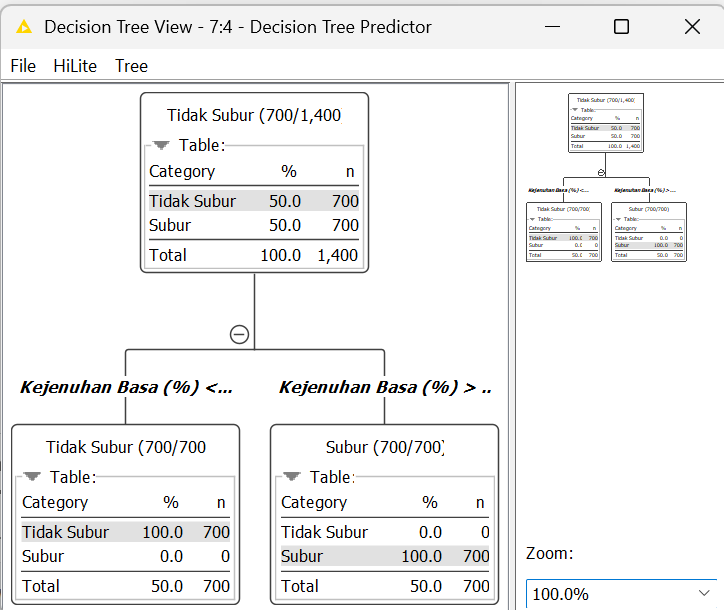


  Tampilan ini mengonfirmasi bahwa model Anda memiliki pemisahan yang sangat tegas (skor murni), di mana ambang batas nilai Kejenuhan Basa secara langsung menentukan apakah suatu lahan masuk kategori Subur atau Tidak Subur tanpa ada data yang tercampur (zero impurity).



#### **f. Scorer (JavaScript)**

Node Scorer digunakan untuk membandingkan hasil prediksi model dengan data yang sebenarnya (fakta di lapangan):

* Actual Column $\rightarrow$ Data asli atau jawaban yang benar.
* Predicted Column $\rightarrow$ Hasil tebakan atau prediksi dari model.

Perbandingan ini dilakukan untuk menghitung tingkat akurasi dan melihat di mana model membuat kesalahan melalui Confusion Matrix.

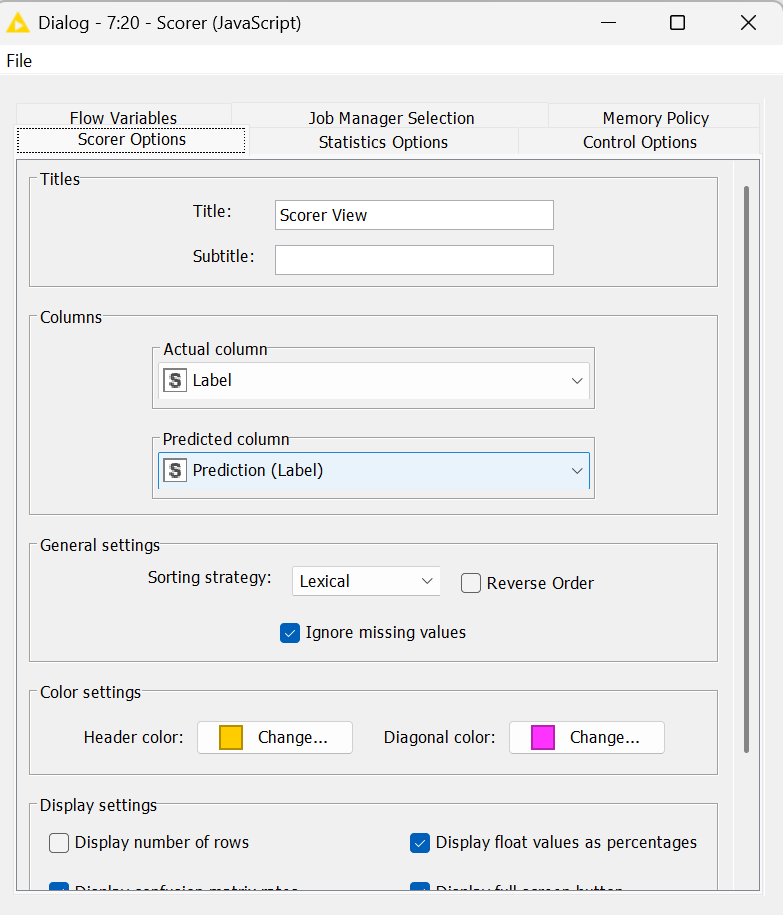



Node Scorer View digunakan untuk mengukur seberapa baik model dalam memprediksi data pengujian:

* **Confusion Matrix** $\rightarrow$ Tabel perbandingan antara prediksi model dengan kenyataan di lapangan.
* **Overall Accuracy** $\rightarrow$ Persentase total prediksi yang benar dilakukan oleh model.

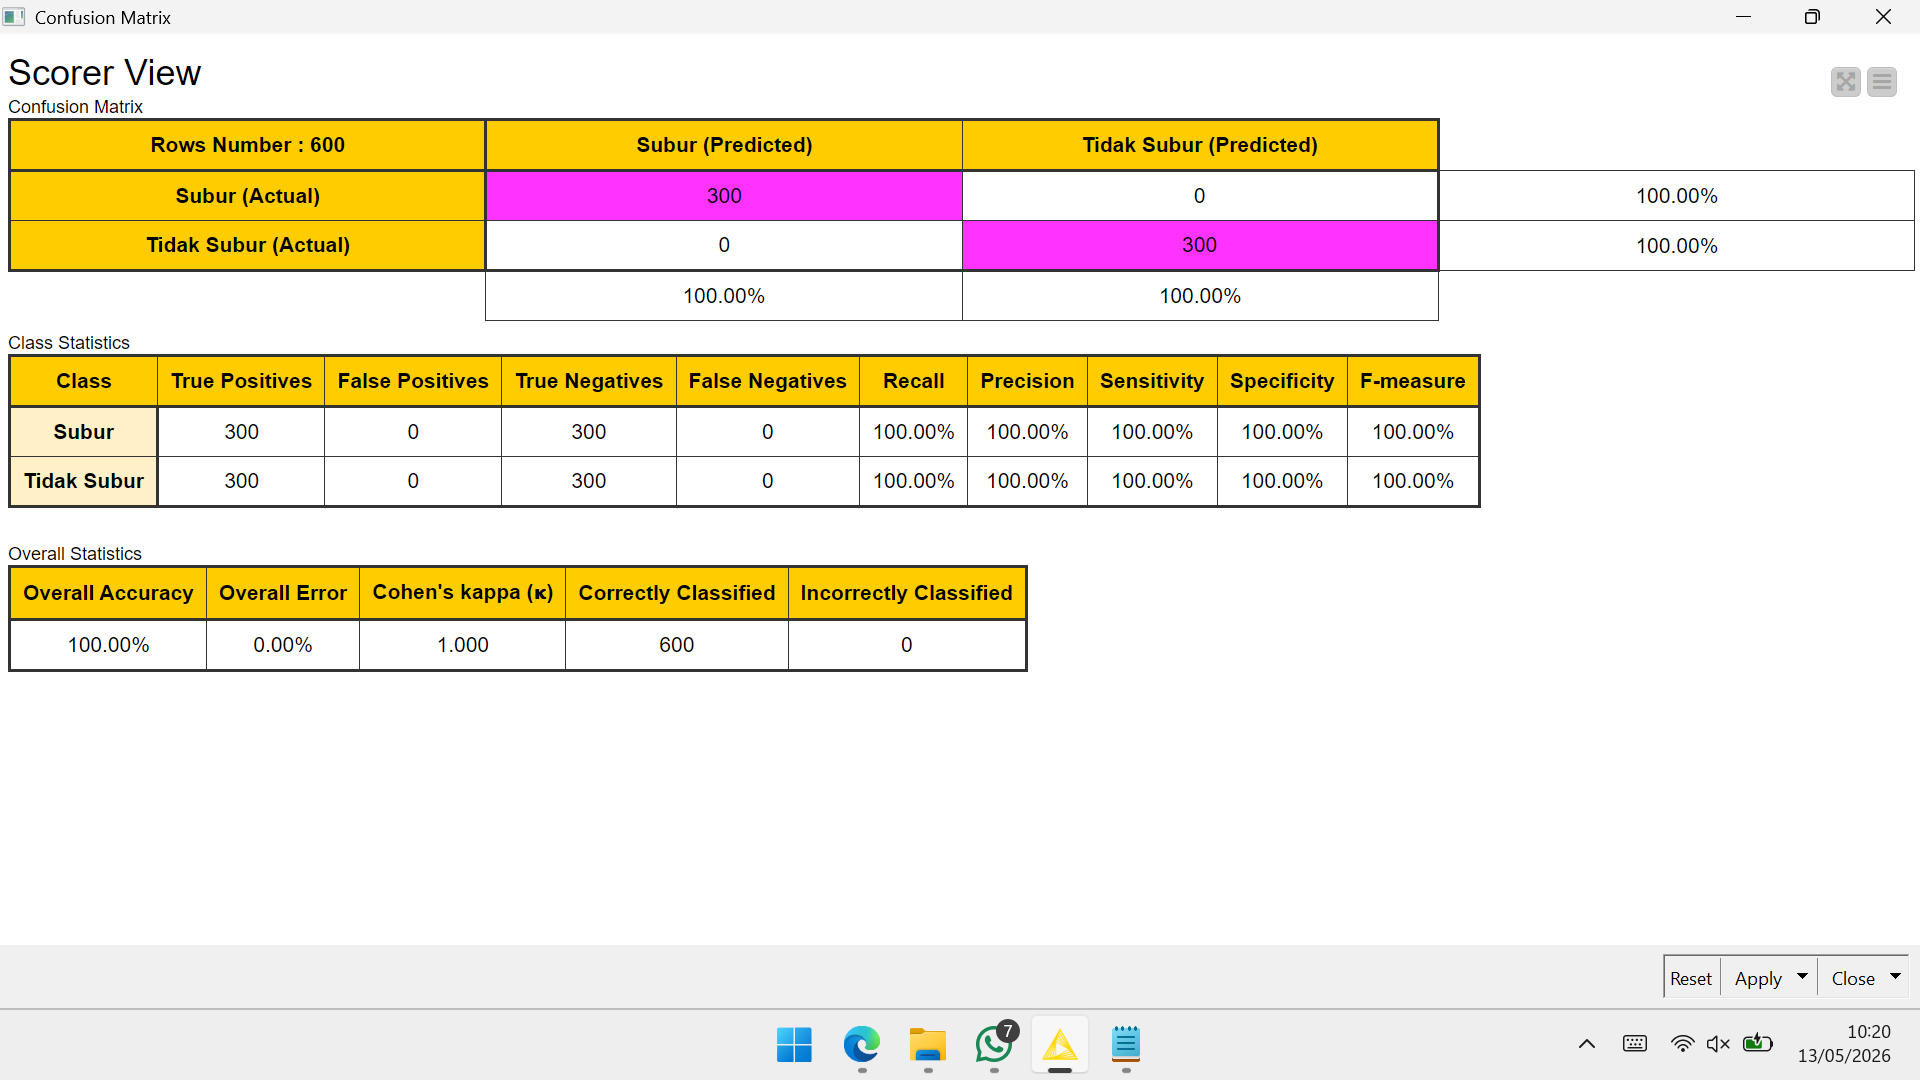


Berikut adalah rincian data performa model Anda yang sangat luar biasa:

* Confusion Matrix (Tabel Atas)

  * Subur (Actual) diprediksi Subur: 300 data (Benar).

  * Tidak Subur (Actual) diprediksi Tidak Subur: 300 data (Benar).

  * Kesalahan Prediksi: 0 (Tidak ada data yang salah tebak).

  * Artinya, dari total 600 baris data testing, model menjawab semuanya dengan benar.


* Class Statistics (Tabel Tengah)

  * Recall & Precision (100.00%): Model memiliki kemampuan sempurna dalam mengenali kelas "Subur" maupun "Tidak Subur" tanpa ada yang terlewat atau tertukar.

  * F-measure (100.00%): Keseimbangan antara ketepatan dan kepekaan model berada di angka maksimal.


* Overall Statistics (Tabel Bawah)

  * Overall Accuracy (100.00%): Model Anda memiliki akurasi sempurna. Semua data diprediksi dengan tepat.

  * Overall Error (0.00%): Tidak ada kesalahan sama sekali dalam proses pengujian ini.

  * Correctly Classified (600): Sebanyak 600 data berhasil diklasifikasikan dengan benar.

  * Incorrectly Classified (0): Tidak ada satu pun data yang gagal diklasifikasikan.


#### **g. Random Forest Learner**

Node Random Forest Learner (Tree Views) digunakan untuk meninjau satu per satu pohon keputusan yang telah dibentuk oleh algoritma Random Forest:

* Ensemble Learning $\rightarrow$ Kumpulan dari banyak pohon keputusan (dalam gambar Anda terdapat 50 model/pohon).
* Sub-sampling $\rightarrow$ Setiap pohon hanya mempelajari sebagian kecil data secara acak untuk menghindari kesalahan prediksi yang sama.

Visualisasi ini membantu kita melihat bagaimana ribuan data dipecah menjadi logika-logika kecil oleh banyak pohon yang berbeda.

Berikut adalah rincian dari salah satu pohon (Model ke-1) yang ditampilkan:

* Jumlah Model (50 model(s) in total): Anda telah melatih model untuk membuat 50 pohon keputusan. Angka "1" di kotak input menunjukkan bahwa Anda sedang melihat visualisasi untuk Pohon Pertama.

* Akar Pohon (Root Node): Pada pohon spesifik ini, ia hanya mengambil sampel yang sangat kecil (terlihat dari n = 1 di tabel). Ini adalah karakteristik Random Forest yang menggunakan teknik Bootstrapping (mengambil sampel acak).

* Atribut Penentu (Kejenuhan Basa): Sama seperti model sebelumnya, variabel ini tetap menjadi indikator kuat bahkan saat data diacak.

* Logika Klasifikasi:

  * Jika Kejenuhan Basa $\le$ 59.555, diklasifikasikan sebagai Tidak Subur.
  * Jika Kejenuhan Basa > 59.555, diklasifikasikan sebagai Subur.

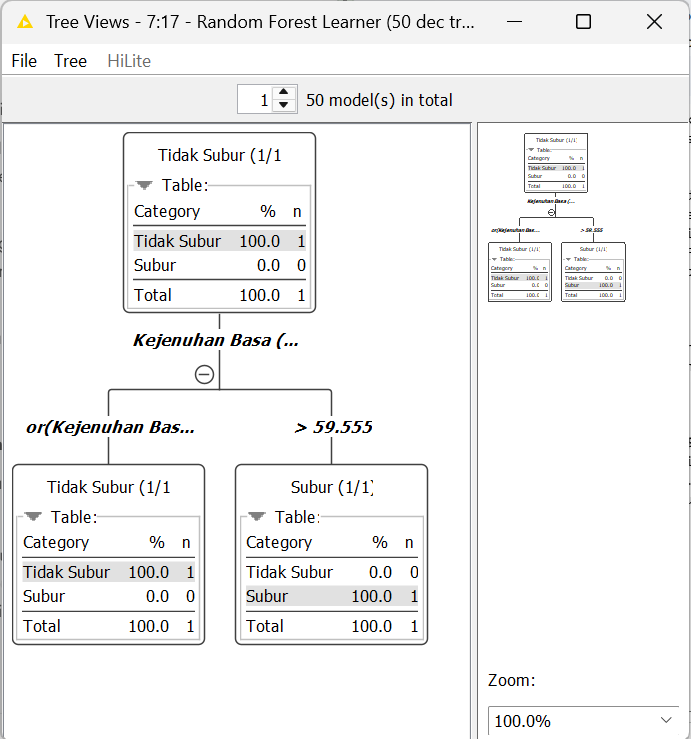


hasil akhirnya (prediksi akhir) bukan diambil dari satu pohon ini saja, melainkan hasil "Voting" terbanyak dari seluruh 50 pohon tersebut. Ini alasan mengapa Random Forest biasanya jauh lebih akurat dan tangguh dibandingkan satu Decision Tree tunggal.


#### **h. Tree Ensemble Statistics**

Node Tree Ensemble Statistics digunakan untuk mengevaluasi struktur internal dari model Random Forest secara keseluruhan:

* Kompleksitas Model $\rightarrow$ Melihat seberapa dalam pohon-pohon yang terbentuk.

* Kesehatan Algoritma $\rightarrow$ Memastikan tidak ada pohon yang terlalu dominan atau terlalu dangkal (underfitting/overfitting).

Statistik ini memberikan gambaran tentang "perilaku" rata-rata dari 50 pohon yang Anda buat.

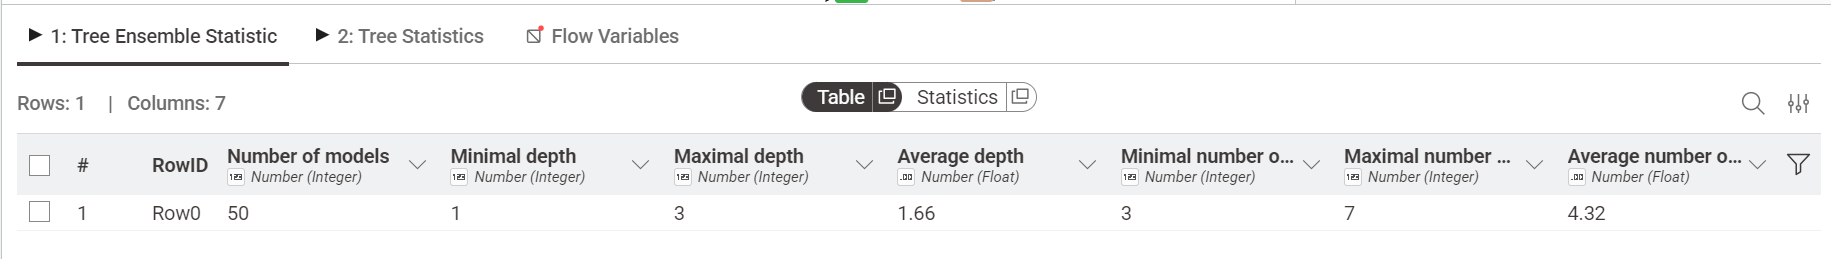


Berikut adalah penjelasan untuk setiap kolom statistik yang muncul:

* Number of models (50): Konfirmasi bahwa Anda menggunakan 50 pohon keputusan dalam satu model Random Forest ini.

* Minimal depth (1): Ada pohon yang sangat sederhana yang hanya memiliki 1 tingkat percabangan (satu aturan saja).

* Maximal depth (3): Pohon yang paling kompleks di dalam hutan Anda memiliki 3 tingkat percabangan. Ini menunjukkan model Anda cukup ringkas dan tidak terlalu rumit.

* Average depth (1.66): Secara rata-rata, pohon-pohon di model Anda memiliki kedalaman sekitar 1,6 tingkat. Ini artinya mayoritas pohon hanya membutuhkan 1 atau 2 pertanyaan logika untuk menentukan kesimpulan.

* Minimal/Maximal number of nodes (3 - 7): Menunjukkan jumlah total kotak (node) dalam satu pohon. Paling sedikit ada 3 node, dan paling banyak ada 7 node.

* Average number of nodes (4.32): Secara rata-rata, setiap pohon dalam Random Forest Anda terdiri dari sekitar 4 node.


Struktur model initergolong sederhana dan efisien. Dengan kedalaman maksimal hanya 3, model ini sangat mudah diinterpretasikan dan kecil kemungkinannya untuk mengalami overfitting (menghafal data), karena ia tidak membuat aturan yang terlalu detail atau dipaksakan.

#### **i. Random Forest Predictor**

Node Predictor (Decision Tree/Random Forest) menghasilkan tabel ini untuk menunjukkan bagaimana model memberikan label pada data baru:

* Label (Actual) $\rightarrow$ Merupakan data asli atau kondisi riil di lapangan.
* Prediction (Label) $\rightarrow$ Merupakan hasil prediksi atau "tebakan" dari model AI.



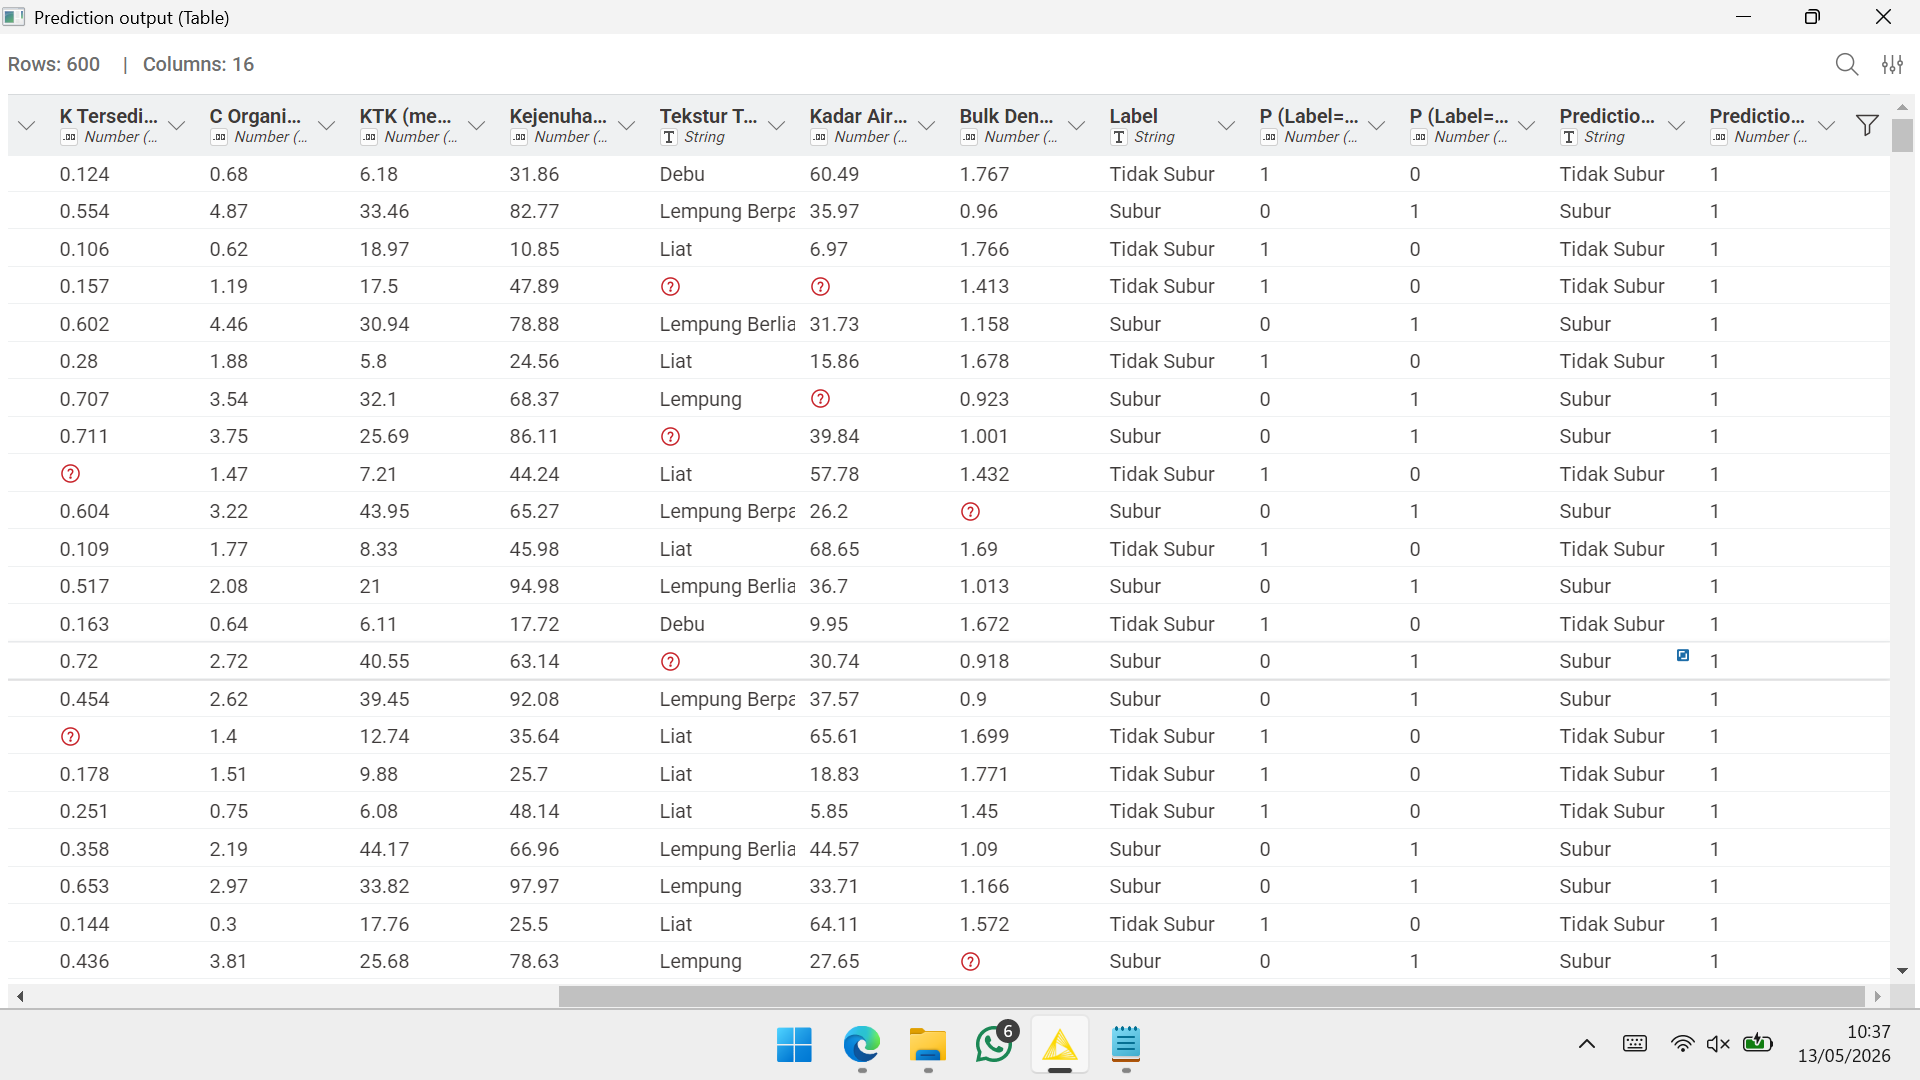



Sesuai dengan tampilan pada gambar diatas, berikut adalah rinciannya:

* Rows: 600: Tabel ini menampilkan hasil pengujian terhadap 600 baris data testing (hasil dari pembagian 30% pada Table Partitioner sebelumnya).

* Kolom Atribut: Menampilkan variabel input seperti K Tersedia, C Organik, KTK, Kejenuhan Basa, Tekstur Tanah, dsb.

* Kolom Prediksi & Probabilitas:

  * Label: Nilai asli (Contoh: "Tidak Subur" atau "Subur").
  * Prediction (Label): Hasil keputusan model. Jika nilai di kolom ini sama dengan kolom Label, maka prediksi model Benar.
  * P (Label=...): Merupakan nilai probabilitas atau tingkat kepercayaan model. Misalnya, jika $P(Subur) = 1$, maka model 100% yakin data tersebut adalah Subur.

* Contoh Pembacaan Baris:

  * Baris 1: Label asli "Tidak Subur", Prediksi "Tidak Subur". (Hasil: Tepat).

  * Baris 2: Label asli "Subur", Prediksi "Subur". (Hasil: Tepat).

#### **j. Scorer (JavaScript)**

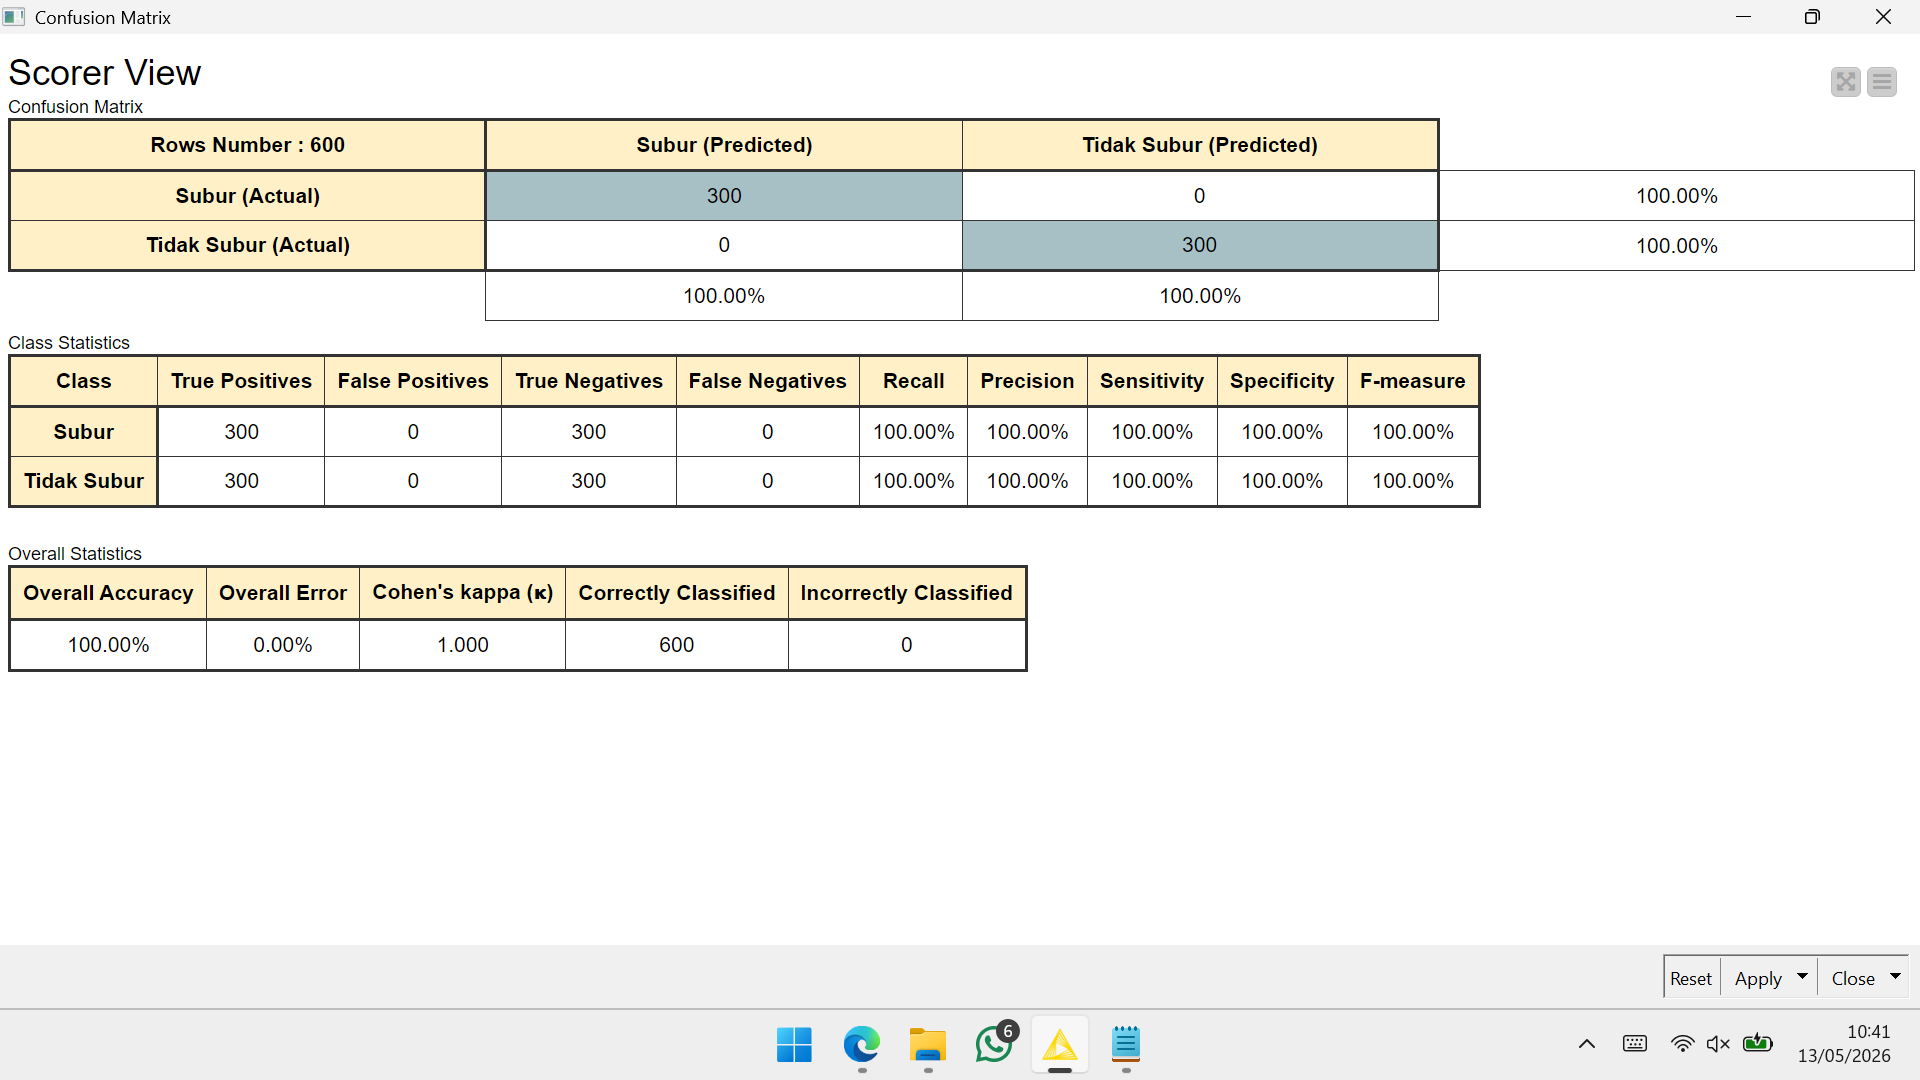


Berdasarkan hasil pengujian pada gambar Scorer View untuk Random Forest, datanya adalah sebagai berikut:

* 70% Data Training (1.400 baris): Digunakan untuk melatih 50 pohon keputusan memahami pola kesuburan tanah.

* 30% Data Testing (600 baris): Digunakan untuk menguji keakuratan "hutan" pohon keputusan tersebut.

* Hasil Evaluasi (Sangat Akurat):

  * 300 data Subur berhasil diprediksi tepat sebagai Subur.

  * 300 data Tidak Subur berhasil diprediksi tepat sebagai Tidak Subur.

  * Overall Accuracy (100%): Model Random Forest Anda berhasil memprediksi seluruh 600 data testing dengan sempurna tanpa ada kesalahan satu pun (0.00% error).


Model ini bekerja dengan sangat baik pada dataset Anda. Penggunaan 50 pohon keputusan memberikan kepastian prediksi yang maksimal, terbukti dengan skor Precision, Recall, dan F-measure yang semuanya mencapai angka 100%.

#### **k. ROC Curve**

Node ROC Curve menampilkan kemampuan model dalam membedakan antara kelas "Subur" dan "Tidak Subur". Grafik ini adalah bukti visual dari kualitas model Anda:

* **True Positive Rate (Sumbu Y)** $\rightarrow$ Menunjukkan seberapa banyak data yang benar-benar "Subur" berhasil tertebak dengan benar.
* **False Positive Rate (Sumbu X)** $\rightarrow$ Menunjukkan seberapa sering model "salah sangka" menganggap tanah tidak subur sebagai subur.

Garis orange yang membentuk sudut 90 derajat menunjukkan bahwa model Anda memiliki performa yang ideal.


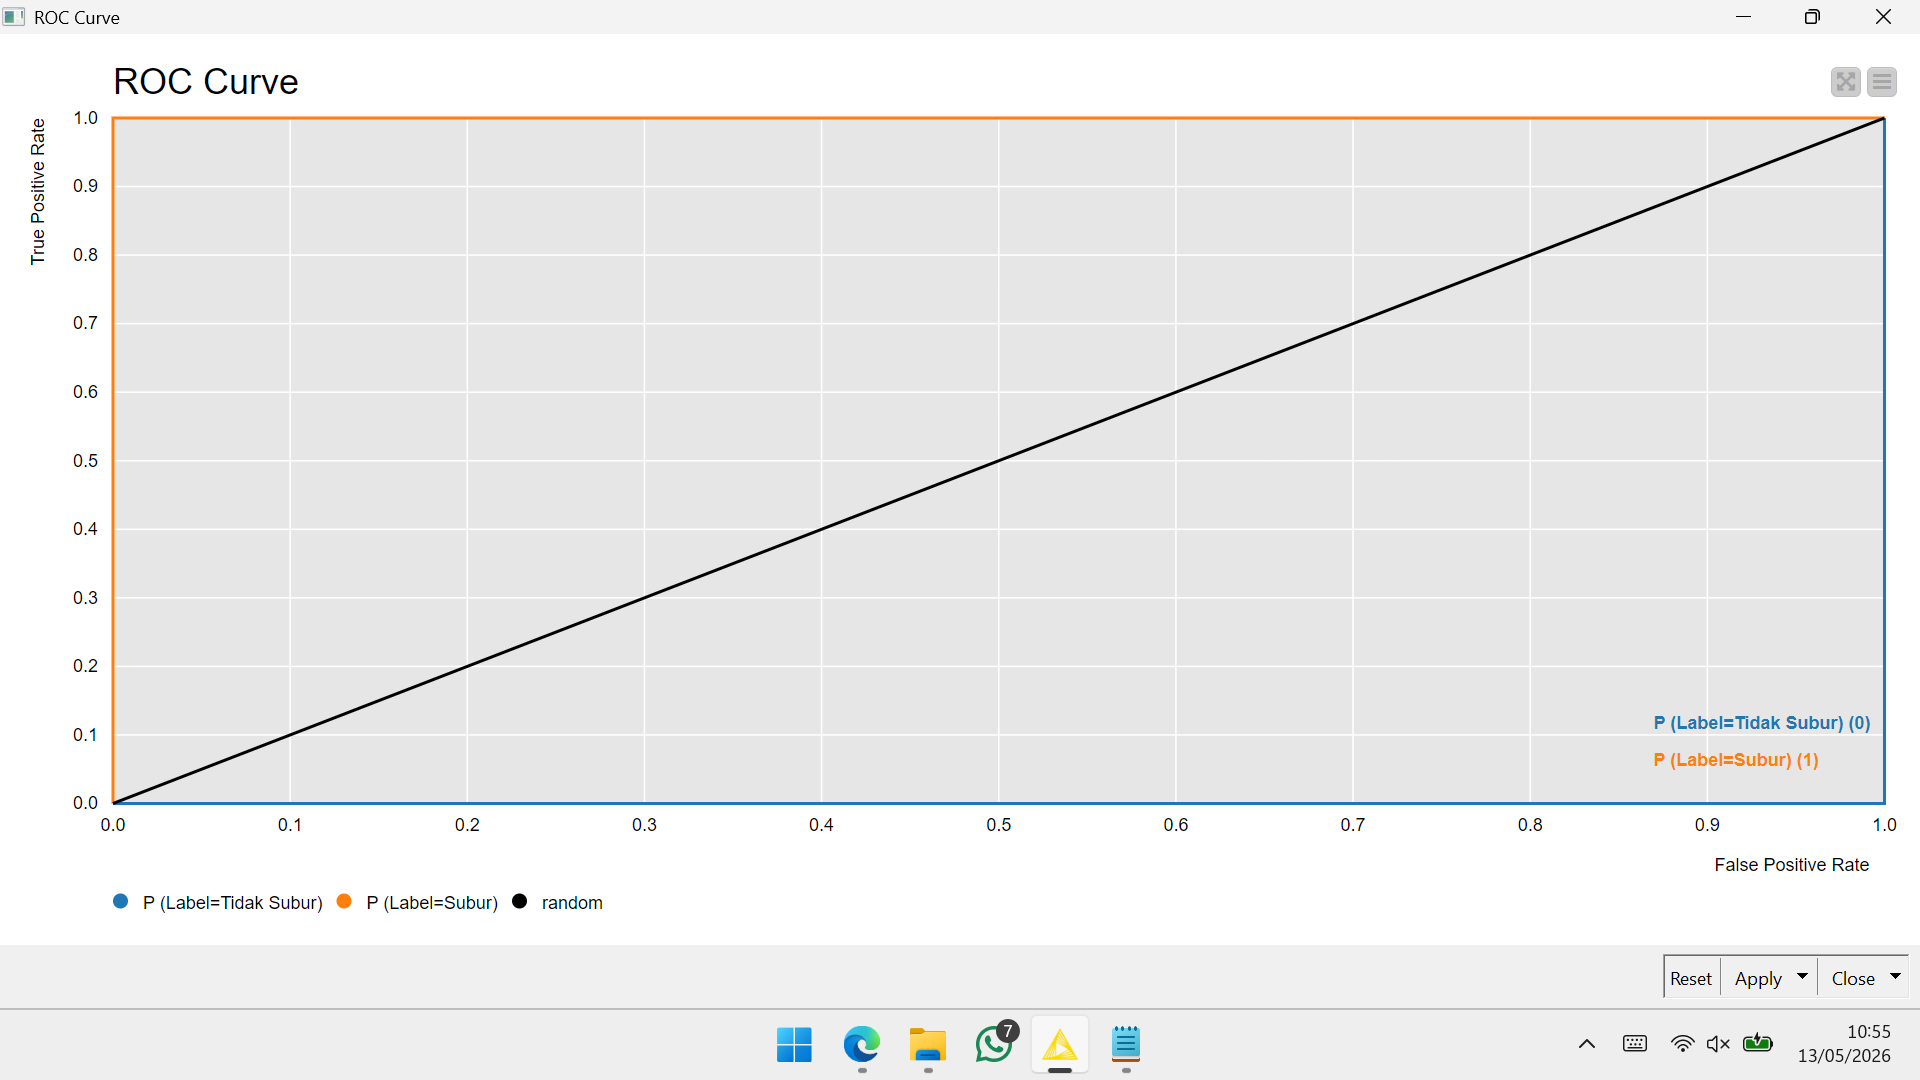


Analisis Grafik:

* **Garis Orange (P Label = Subur)**: Garis ini langsung naik ke angka 1.0 pada True Positive Rate dan tetap di sana. Ini artinya model Anda berhasil mendeteksi seluruh tanah subur tanpa ada satu pun kesalahan (zero false positives).

* **Garis Hitam Diagonal (Random)**: Garis putus-putus diagonal adalah standar minimal. Jika garis orange berada di atas garis hitam, berarti model Anda lebih baik daripada sekadar menebak acak. Karena garis Anda berada jauh di atas, model Anda sangat cerdas.

* **Interpretasi Nilai AUC**: Walaupun tabel angkanya tidak terlihat di gambar ini, grafik seperti ini pasti menghasilkan nilai AUC = 1.000.

  * AUC 1.0 = Model Sempurna.

  * AUC 0.5 = Model sama buruknya dengan menebak acak (koin).


**Hasil Proses Knime**


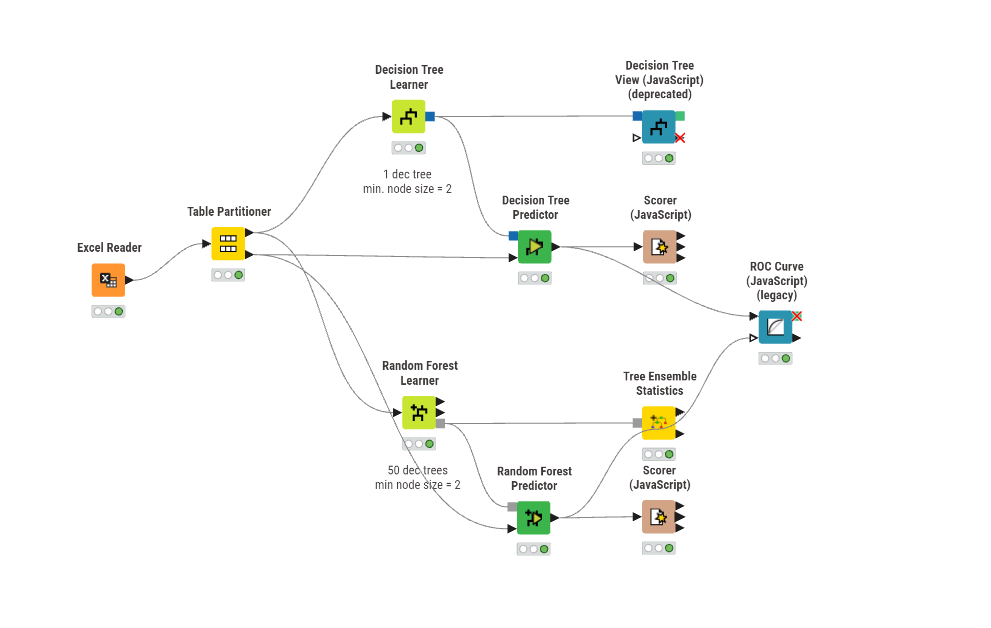

**Kesimpulan**

##### **1. Hasil Model Decision Tree**

* Logika Sederhana: Model ini sangat mudah diinterpretasikan. Ia hanya membutuhkan satu aturan utama, yaitu nilai Kejenuhan Basa.

* Titik Keputusan: Jika Kejenuhan Basa $\le 58.96$, maka tanah dianggap Tidak Subur. Jika $> 58.96$, maka tanah dianggap Subur.

* Performa: Mencapai akurasi 100% pada data testing (600 baris terprediksi benar semua).

##### **2. Hasil Model Random Forest**

* Stabilitas Tinggi: Dengan menggunakan 50 pohon keputusan, model ini jauh lebih tangguh menghadapi variasi data karena menggunakan sistem "voting" dari banyak pohon.

* Kompleksitas Efisien: Meskipun terdiri dari banyak pohon, rata-rata kedalaman pohon hanya 1.66, menunjukkan model tidak "overthinking" dalam mengambil keputusan.

* Performa: Sama seperti Decision Tree, model ini juga meraih akurasi 100% dengan nilai AUC = 1.000 pada grafik ROC Curve.


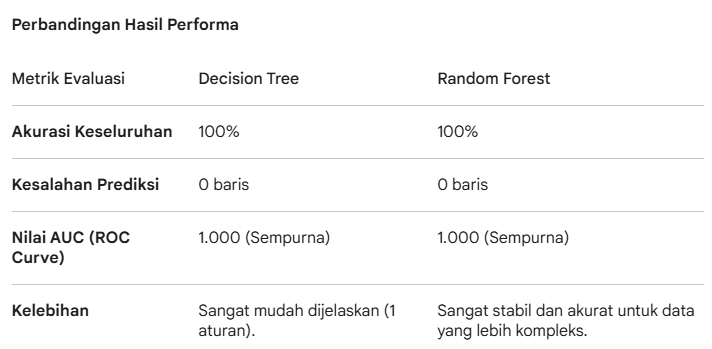



**Kesimpulan Utama**: Tanah dengan **Kejenuhan Basa di atas 58.96%** secara konsisten diklasifikasikan sebagai tanah **Subur**.
